In [58]:
#Load Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import pairwise_distances
from sklearn.manifold import MDS,TSNE
from sklearn.datasets import load_iris

In [59]:
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['Species'] = iris.target_names[iris.target]
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [60]:
iris_df.shape

(150, 5)

In [61]:
X = iris_df.drop('Species', axis=1)
y = iris_df['Species']
target_names = iris.target_names

In [62]:
#Scaling the features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [63]:
#initialize mds
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

In [64]:
df = pd.DataFrame(X_mds, columns=['MDS1', 'MDS2'])
df['Target'] = y
df.head()

,MDS1,MDS2,Target
0,-1.527026,-1.757989,setosa
1,-2.086642,-0.702662,setosa
2,-2.106839,-1.154766,setosa
3,-2.216248,-0.909172,setosa
4,-1.532789,-1.965374,setosa


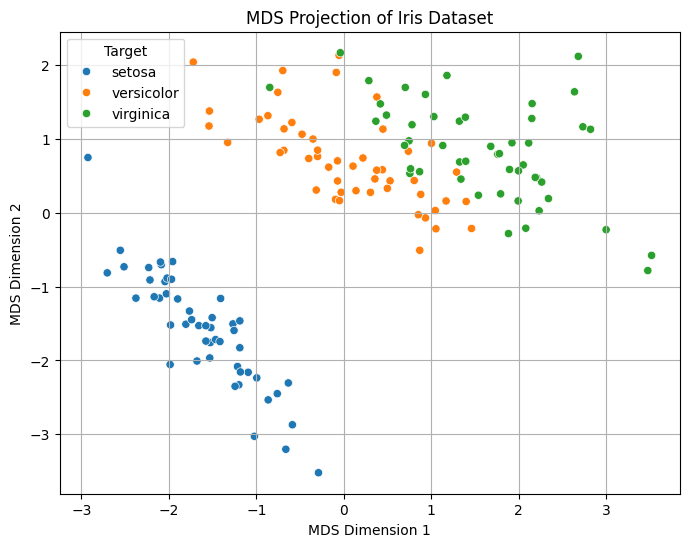

In [65]:
#Visualization
plt.figure(figsize=(8, 6))

# Correcting the indexing to use DataFrame column names
sns.scatterplot(x='MDS1', y='MDS2', hue='Target', data=df)
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS Projection of Iris Dataset')

plt.grid()

plt.show()

In [71]:
# Perform Non-Metric MDS (MMDS)
mmds = MDS(n_components=2, metric=False, random_state=42)
X_mmds = mmds.fit_transform(X_scaled)

# Create a DataFrame for MMDS results
df_mmds = pd.DataFrame(X_mmds, columns=['MMDS1', 'MMDS2'])
df_mmds['Target'] = y

df_mmds.head()

,MMDS1,MMDS2,Target
0,-0.101099,0.443660,setosa
1,0.204624,0.135571,setosa
2,-0.362548,-0.316776,setosa
3,-0.361079,0.321759,setosa
4,0.066627,0.268774,setosa


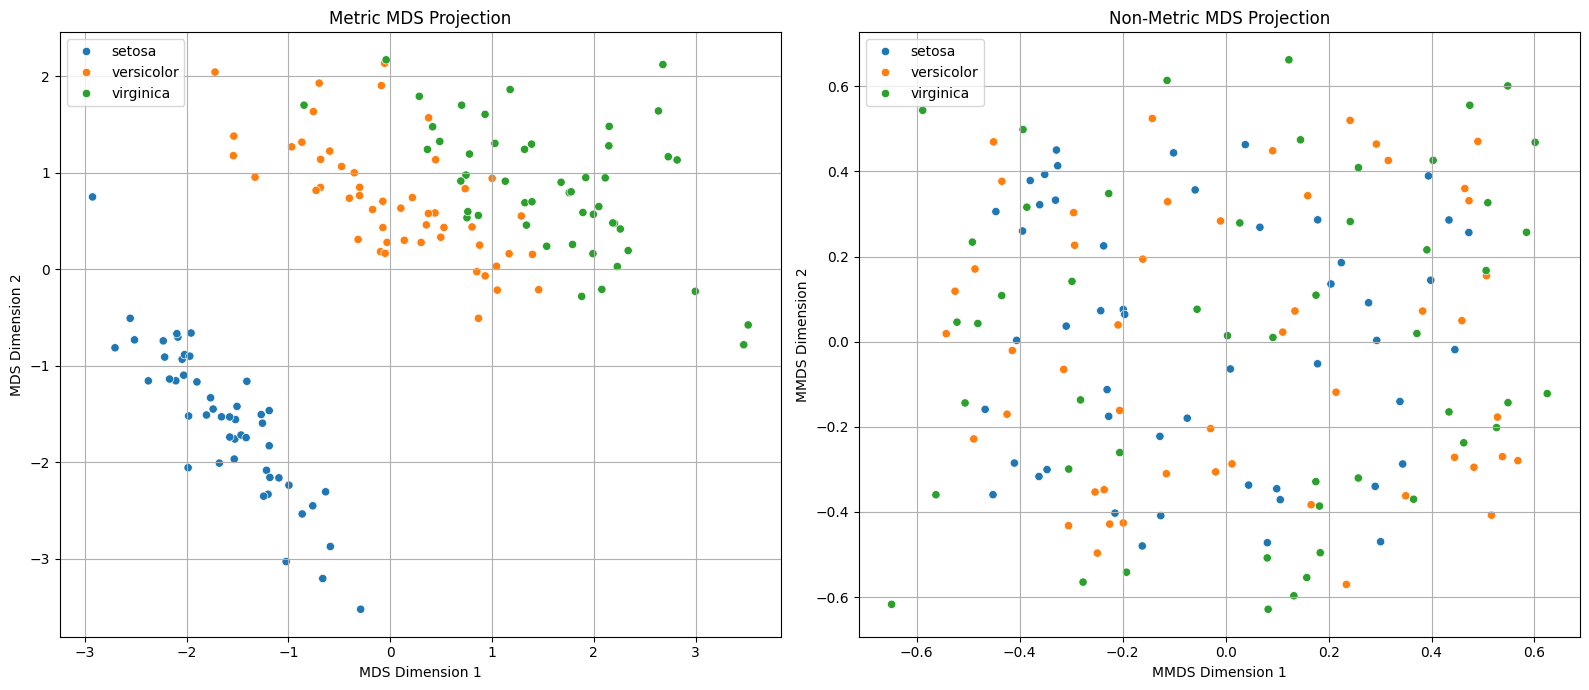

In [72]:
#Visualization
plt.figure(figsize=(16, 7))

# Plot for Metric MDS
plt.subplot(1, 2, 1)
sns.scatterplot(x='MDS1', y='MDS2', hue='Target', data=df)
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('Metric MDS Projection')
plt.legend()
plt.grid()

# Plot for Non-Metric MDS
plt.subplot(1, 2, 2)
sns.scatterplot(x='MMDS1', y='MMDS2', hue='Target', data=df_mmds)
plt.xlabel('MMDS Dimension 1')
plt.ylabel('MMDS Dimension 2')
plt.title('Non-Metric MDS Projection')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()